In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import warnings
warnings.filterwarnings('ignore')

os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

print("TensorFlow:", tf.__version__)
print("All libraries loaded!")

TensorFlow: 2.20.0
All libraries loaded!


In [54]:
from google.colab import drive
drive.mount('/content/drive')

import os
base_drive = '/content/drive/MyDrive/ai_project_synthetic_datasets-20260505T171228Z-3-001/ai_project_synthetic_datasets/part_2_cnn_computer_vision'

print("Files in Part 2 folder:")
print(os.listdir(base_drive))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in Part 2 folder:
['.DS_Store', 'data_dictionary.md', 'labels.csv', 'images']


In [55]:
labels_df = pd.read_csv(f'{base_drive}/labels.csv')
print("Labels CSV loaded!")
print(f"Shape: {labels_df.shape}")
print(f"\nFirst few rows:")
display(labels_df.head())
print(f"\nClass Distribution:")
print(labels_df['class'].value_counts())

# Create folder structure
for split in ['train', 'test']:
    for cls in labels_df['class'].unique():
        os.makedirs(f'dataset/{split}/{cls}', exist_ok=True)

# Split 80-20 per class
for cls in labels_df['class'].unique():
    class_files = labels_df[labels_df['class'] == cls]['filename'].tolist()
    train_files, test_files = train_test_split(
        class_files, test_size=0.2, random_state=7
    )

    for f in train_files:
        src = os.path.join(base_drive, f)
        dst = f'dataset/train/{cls}/{os.path.basename(f)}'
        if os.path.exists(src):
            shutil.copy(src, dst)

    for f in test_files:
        src = os.path.join(base_drive, f)
        dst = f'dataset/test/{cls}/{os.path.basename(f)}'
        if os.path.exists(src):
            shutil.copy(src, dst)

print("\nDataset organized into train/test folders!")
for split in ['train', 'test']:
    for cls in sorted(os.listdir(f'dataset/{split}')):
        count = len(os.listdir(f'dataset/{split}/{cls}'))
        print(f"  {split}/{cls}: {count} images")

Labels CSV loaded!
Shape: (480, 2)

First few rows:


,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal



Class Distribution:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64

Dataset organized into train/test folders!
  train/dent: 96 images
  train/normal: 96 images
  train/scratch: 96 images
  train/stain: 96 images
  test/dent: 24 images
  test/normal: 24 images
  test/scratch: 24 images
  test/stain: 24 images


Total Classes : 4
Class Names   : ['dent', 'normal', 'scratch', 'stain']

Total Train Images : 384
Total Test Images  : 96


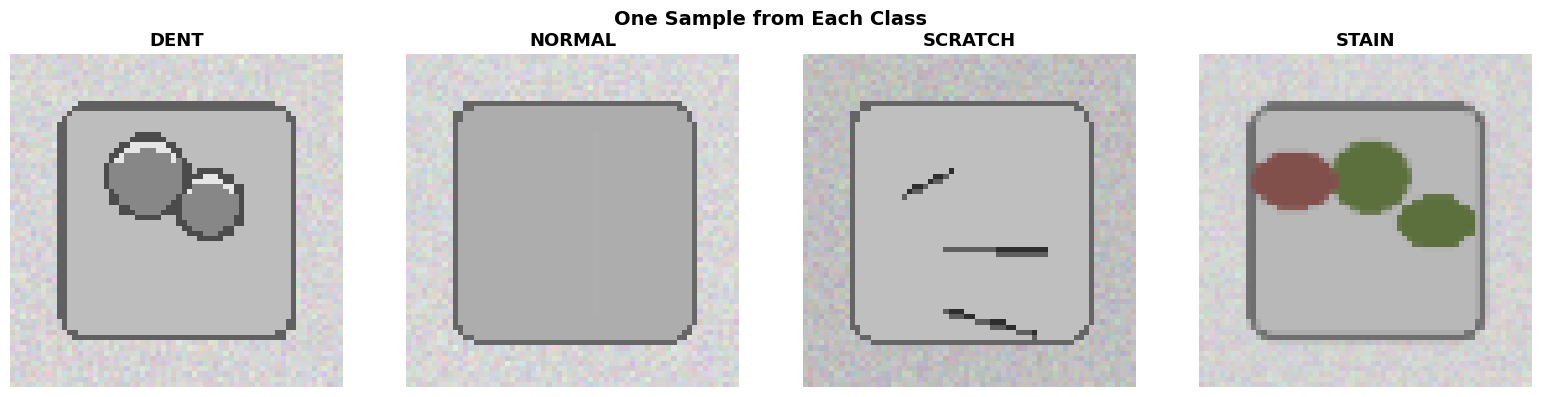


Original image size : (96, 96)
Resizing all to     : 64x64 pixels
Any class imbalance : {'normal': 120, 'scratch': 120, 'dent': 120, 'stain': 120}


In [56]:
classes = sorted(os.listdir('dataset/train'))
print(f"Total Classes : {len(classes)}")
print(f"Class Names   : {classes}")

total_train = sum(len(os.listdir(f'dataset/train/{c}')) for c in classes)
total_test  = sum(len(os.listdir(f'dataset/test/{c}'))  for c in classes)
print(f"\nTotal Train Images : {total_train}")
print(f"Total Test Images  : {total_test}")

# Sample image from each class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls in enumerate(classes):
    img_file = os.listdir(f'dataset/train/{cls}')[0]
    img = load_img(f'dataset/train/{cls}/{img_file}', target_size=(64,64))
    axes[i].imshow(img)
    axes[i].set_title(cls.upper(), fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('One Sample from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/sample_class_images.png', dpi=100, bbox_inches='tight')
plt.show()

# Check image size
sample_path = f"dataset/train/{classes[0]}/{os.listdir(f'dataset/train/{classes[0]}')[0]}"
img_check = load_img(sample_path)
print(f"\nOriginal image size : {img_check.size}")
print(f"Resizing all to     : 64x64 pixels")
print(f"Any class imbalance : {labels_df['class'].value_counts().to_dict()}")

In [57]:
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)

# Test generator - only normalize
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    'dataset/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices : {train_gen.class_indices}")
print(f"Train batches : {len(train_gen)}")
print(f"Test batches  : {len(test_gen)}")

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.

Class indices : {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}
Train batches : 12
Test batches  : 3


In [58]:
num_classes = len(classes)

model = keras.Sequential([
    # Block 1 - Basic edge detection
    layers.Conv2D(16, (3,3), activation='relu',
                  padding='same', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(2, 2),
    layers.BatchNormalization(),

    # Block 2 - Pattern recognition
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.Conv2D(32, (5,5), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.BatchNormalization(),

    # Block 3 - High level features
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0008),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 582,340 (2.22 MB)

 Trainable params: 582,244 (2.22 MB)

 Non-trainable params: 96 (384.00 B)


Total parameters: 582,340


In [59]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=test_gen,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch : {len(history.history['accuracy'])}")
print(f"Best Train Accuracy       : {max(history.history['accuracy'])*100:.2f}%")
print(f"Best Val Accuracy         : {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 481ms/step - accuracy: 0.3021 - loss: 1.7344 - val_accuracy: 0.2500 - val_loss: 1.3850
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 625ms/step - accuracy: 0.3490 - loss: 1.3433 - val_accuracy: 0.2604 - val_loss: 1.3854
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 599ms/step - accuracy: 0.4323 - loss: 1.1619 - val_accuracy: 0.3438 - val_loss: 1.3838
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 779ms/step - accuracy: 0.4193 - loss: 1.0914 - val_accuracy: 0.2500 - val_loss: 1.3913
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - accuracy: 0.5495 - loss: 0.9499 - val_accuracy: 0.2708 - val_loss: 1.4010
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 564ms/step - accuracy: 0.5885 - loss: 0.8778 - val_accuracy: 0.2500 - val_loss: 1.4271
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 425ms/step - accuracy: 0.5625 - loss: 0.8997 - val_accuracy: 0.2604 - val_loss: 1.4915
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.

Training stopped a

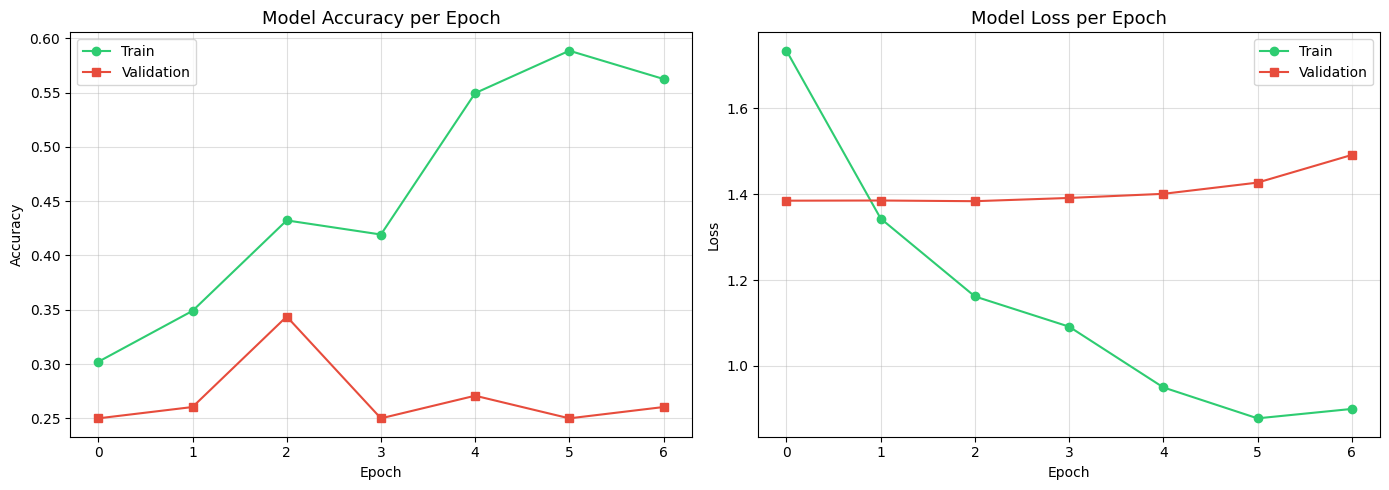

Accuracy/Loss curves saved!


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', marker='o', color='#2ecc71')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s', color='#e74c3c')
axes[0].set_title('Model Accuracy per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Loss
axes[1].plot(history.history['loss'],     label='Train', marker='o', color='#2ecc71')
axes[1].plot(history.history['val_loss'], label='Validation', marker='s', color='#e74c3c')
axes[1].set_title('Model Loss per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("Accuracy/Loss curves saved!")

Classification Report:
              precision    recall  f1-score   support

        dent       0.00      0.00      0.00        24
      normal       0.31      1.00      0.47        24
     scratch       0.00      0.00      0.00        24
       stain       0.50      0.38      0.43        24

    accuracy                           0.34        96
   macro avg       0.20      0.34      0.22        96
weighted avg       0.20      0.34      0.22        96



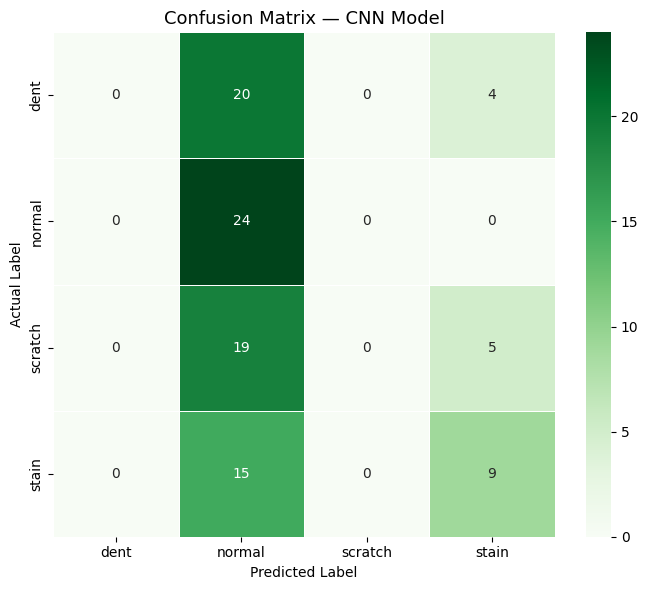

Confusion matrix saved!


In [61]:
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5)
plt.title('Confusion Matrix — CNN Model', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

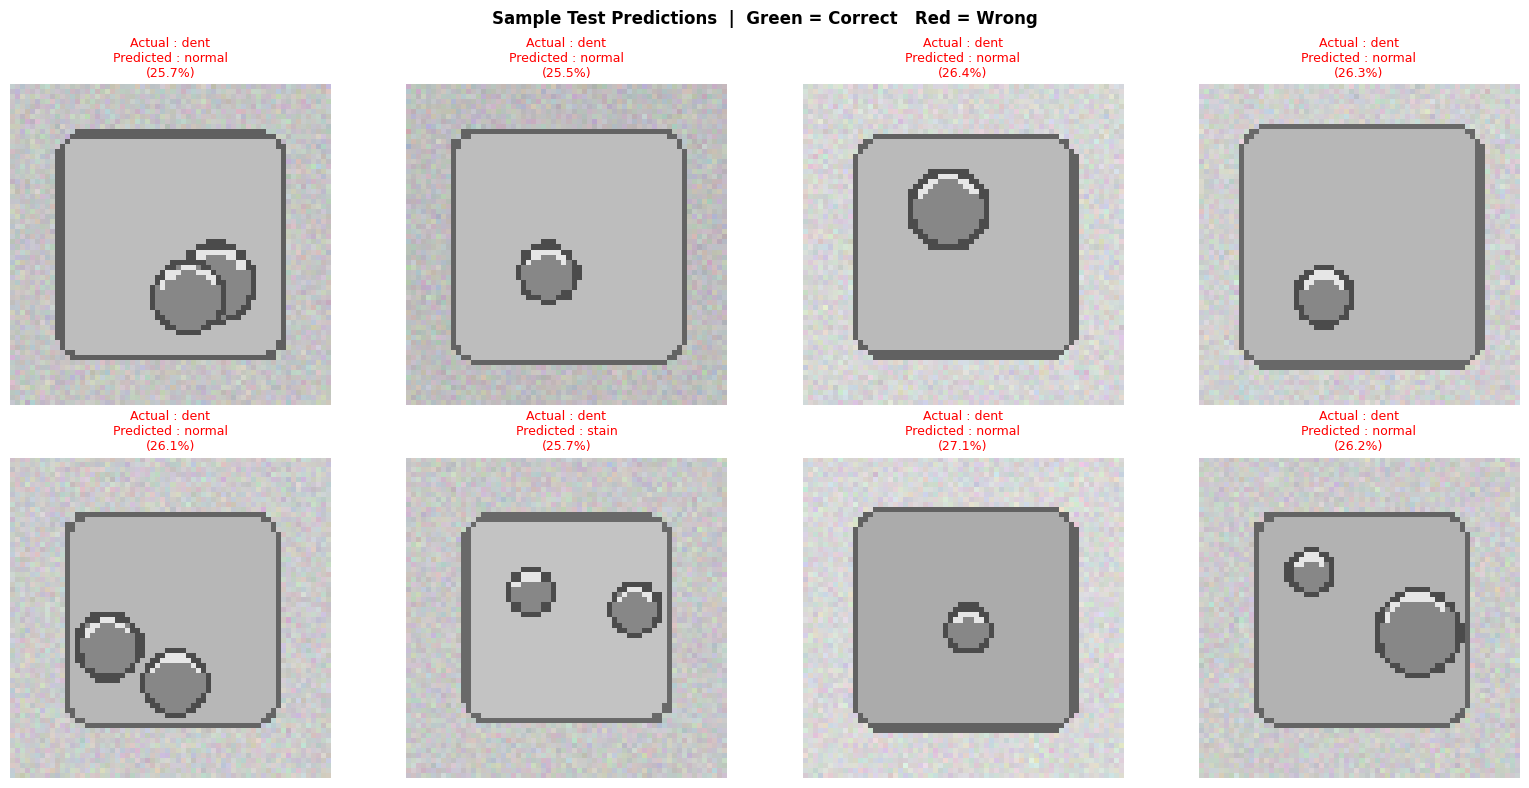

Sample predictions saved!


In [62]:
test_gen.reset()
img_batch, lbl_batch = next(test_gen)
preds = model.predict(img_batch, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    img        = img_batch[i]
    true_label = class_names[np.argmax(lbl_batch[i])]
    pred_label = class_names[np.argmax(preds[i])]
    confidence = np.max(preds[i]) * 100

    axes[i].imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f"Actual : {true_label}\nPredicted : {pred_label}\n({confidence:.1f}%)",
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('Sample Test Predictions  |  Green = Correct   Red = Wrong',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sample predictions saved!")

In [63]:
from google.colab import files

files.download('results/sample_class_images.png')
files.download('results/accuracy_loss_curves.png')
files.download('results/confusion_matrix.png')
files.download('sample_predictions/prediction_outputs.png')

print("\nNotebook bhi download karo:")
print("File → Download → Download .ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Notebook bhi download karo:
File → Download → Download .ipynb
